# Health Insurance Claims Analytics

In [3]:
import torch
import numpy as np
import pandas as pd
import transformers

from autogluon.tabular import TabularPredictor

print(f"--- Environment Report ---")
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"Current device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"NumPy: {np.__version__}")
print(f"Torch: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

# Test AutoGluon
try:
    print(f"AutoGluon: TabularPredictor imported!")
except Exception as e:
    print(f"AutoGluon Error: {e}")

--- Environment Report ---
Is CUDA available? True
Current device: NVIDIA GeForce RTX 5070 Laptop GPU
NumPy: 1.26.4
Torch: 2.9.1+cu128
Transformers version: 4.57.6
AutoGluon: TabularPredictor imported!


In [4]:
#!pip install autogluon.multimodal
import autogluon.multimodal
from autogluon.multimodal import MultiModalPredictor

# Check version
print(f"AutoGluon Multimodal version: {autogluon.multimodal.__version__}")

# Check if it can initialize a dummy predictor
try:
    predictor = MultiModalPredictor(label="label")
    print("Installation verified: Predictor initialized successfully.")
except Exception as e:
    print(f"Initialization failed: {e}")

AutoGluon Multimodal version: 1.5.0
Installation verified: Predictor initialized successfully.


# Exploratory Data Analysis - Summary

In [5]:
# EDA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('Data/enhanced_health_insurance_claims.csv')

# Basic Overview
print(df.info())
print(df.describe())
print(f"Missing values:\n{df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ClaimID                  4500 non-null   object 
 1   PatientID                4500 non-null   object 
 2   ProviderID               4500 non-null   object 
 3   ClaimAmount              4500 non-null   float64
 4   ClaimDate                4500 non-null   object 
 5   DiagnosisCode            4500 non-null   object 
 6   ProcedureCode            4500 non-null   object 
 7   PatientAge               4500 non-null   int64  
 8   PatientGender            4500 non-null   object 
 9   ProviderSpecialty        4500 non-null   object 
 10  ClaimStatus              4500 non-null   object 
 11  PatientIncome            4500 non-null   float64
 12  PatientMaritalStatus     4500 non-null   object 
 13  PatientEmploymentStatus  4500 non-null   object 
 14  ProviderLocation        

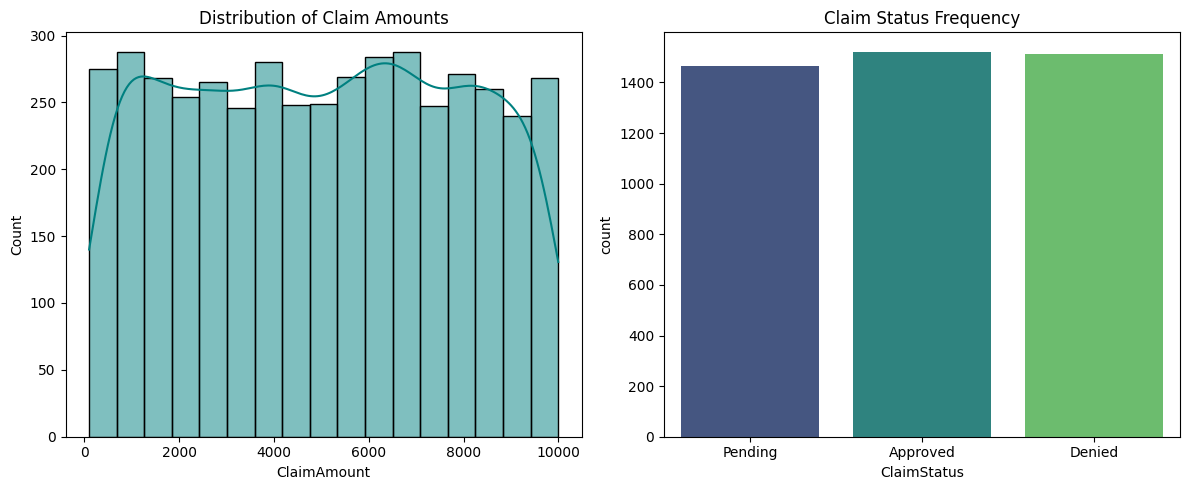

In [9]:
plt.figure(figsize=(12, 5))

# Distribution of Claim Amounts
plt.subplot(1, 2, 1)
sns.histplot(df['ClaimAmount'], kde=True, color='teal')
plt.title('Distribution of Claim Amounts')

# Claim Status Counts (fixed warning)
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='ClaimStatus', hue='ClaimStatus', palette='viridis', legend=False)
plt.title('Claim Status Frequency')

plt.tight_layout()
plt.show()

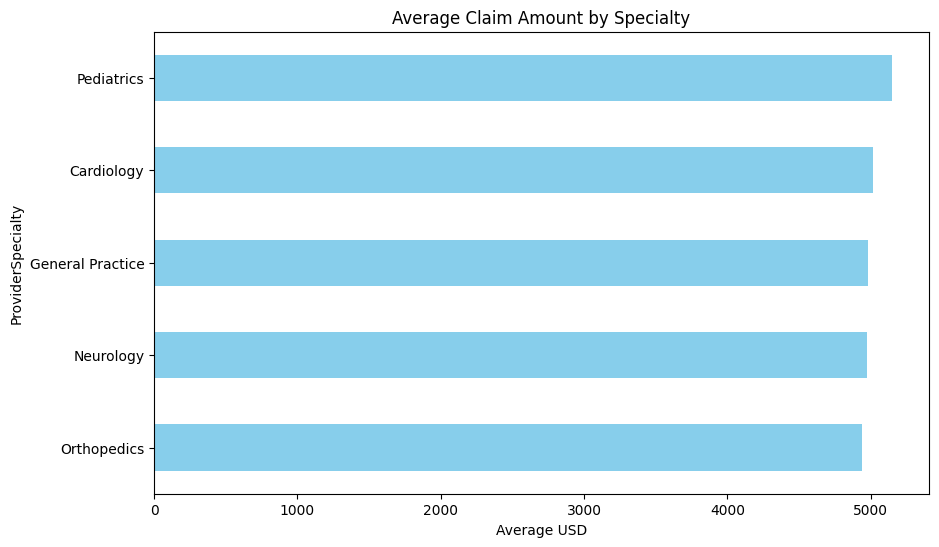

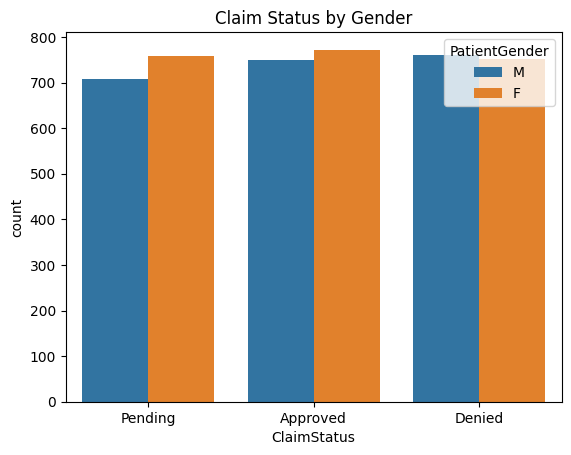

In [6]:
# Average Claim Amount by Provider Specialty
plt.figure(figsize=(10, 6))
df.groupby('ProviderSpecialty')['ClaimAmount'].mean().sort_values().plot(kind='barh', color='skyblue')
plt.title('Average Claim Amount by Specialty')
plt.xlabel('Average USD')
plt.show()

# Claim Status by Patient Gender
sns.countplot(data=df, x='ClaimStatus', hue='PatientGender')
plt.title('Claim Status by Gender')
plt.show()

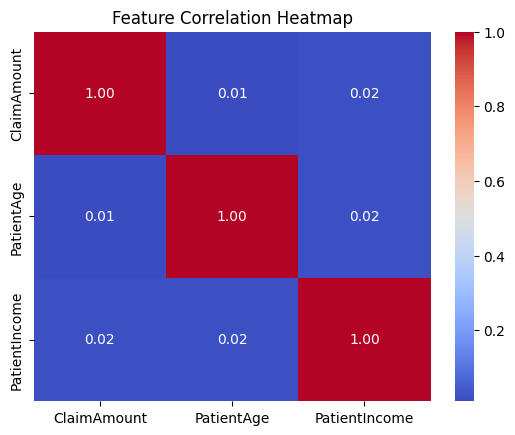

In [7]:
# Selecting only numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

# Predictive Analytics

In [14]:
from autogluon.tabular import TabularDataset, TabularPredictor

# 1. Load the data (AutoGluon has its own wrapper for pandas)
train_data = TabularDataset('Data/enhanced_health_insurance_claims.csv')

# drop the ClaimDate as that is not very useful in this context for prediction
train_data_nodate = train_data.drop(columns=['ClaimDate'])


# 2. Define the target column (e.g., trying to predict if a claim is Denied/Approved)
label = 'ClaimStatus'

# 3. Train! 'best_quality' enables multi-layer stacking and bagging
predictor = TabularPredictor(label=label).fit(
    train_data_nodate, 
    presets='best_quality', 
    ag_args_fit={'num_gpus': 1}  # Enable GPU for capable models
)

Loaded data from: Data/enhanced_health_insurance_claims.csv | Columns = 17 / 17 | Rows = 4500 -> 4500
No path specified. Models will be saved in: "AutogluonModels/ag-20260422_030539"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.19
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
CPU Count:          24
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 7.95/7.96 GB
Total GPU Memory:   Free: 7.95 GB, Allocated: 0.01 GB, Total: 7.96 GB
GPU Count:          1
Memory Avail:       11.99 GB / 15.34 GB (78.2%)
Disk Space Avail:   803.28 GB / 1006.85 GB (79.8%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configur

In [16]:
predictor = TabularPredictor.load("/home/maulik/CS104/Final/AutogluonModels/ag-20260422_030539")

In [17]:
# Leaderboard: See all models ranked by performance
leaderboard = predictor.leaderboard()
print(leaderboard)

                        model  score_val eval_metric  pred_time_val  \
0         WeightedEnsemble_L3   0.420000    accuracy       1.039161   
1   NeuralNetTorch_r76_BAG_L2   0.414222    accuracy       0.628448   
2   NeuralNetTorch_r14_BAG_L2   0.402222    accuracy       0.623930   
3   NeuralNetTorch_r79_BAG_L2   0.398222    accuracy       0.624503   
4   NeuralNetTorch_r71_BAG_L2   0.396889    accuracy       0.628092   
..                        ...        ...         ...            ...   
68     ExtraTrees_r126_BAG_L1   0.327778    accuracy       0.102556   
69      ExtraTreesEntr_BAG_L1   0.327778    accuracy       0.127001   
70   RandomForest_r127_BAG_L1   0.327111    accuracy       0.096516   
71      ExtraTrees_r49_BAG_L1   0.326222    accuracy       0.122615   
72      ExtraTreesGini_BAG_L1   0.326222    accuracy       0.123362   

      fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  \
0   284.034484                0.000632           0.059194            3   

In [18]:
# Evaluate 
# 1. Model performance summary (validation scores)
print(predictor.fit_summary())

# 2. Detailed leaderboard with extra info (hyperparameters, etc.)
leaderboard_extra = predictor.leaderboard(extra_info=True)
print(leaderboard_extra)

# 3. Feature importance
importance = predictor.feature_importance(data=train_data)
print(importance)

*** Summary of fit() ***
Estimated performance of each model:
                         model  score_val eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0          WeightedEnsemble_L3   0.420000    accuracy       1.039161  284.034484                0.000632           0.059194            3       True         73
1    NeuralNetTorch_r76_BAG_L2   0.414222    accuracy       0.628448  209.607405                0.073320          73.209348            2       True         70
2    NeuralNetTorch_r14_BAG_L2   0.402222    accuracy       0.623930  208.951032                0.068802          72.552976            2       True         53
3    NeuralNetTorch_r79_BAG_L2   0.398222    accuracy       0.624503  237.154421                0.069375         100.756364            2       True         46
4    NeuralNetTorch_r71_BAG_L2   0.396889    accuracy       0.628092  192.367360                0.072964          55.969303            2       

/home/maulik/miniconda3/envs/autogluon/lib/python3.10/site-packages/autogluon/core/utils/plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')
These features in provided data are not utilized by the predictor and will be ignored: ['ClaimID', 'PatientID', 'ProviderID', 'ClaimDate']
Computing feature importance via permutation shuffling for 12 features using 4500 rows with 5 shuffle sets...


                        model  score_val eval_metric  pred_time_val  \
0         WeightedEnsemble_L3   0.420000    accuracy       1.039161   
1   NeuralNetTorch_r76_BAG_L2   0.414222    accuracy       0.628448   
2   NeuralNetTorch_r14_BAG_L2   0.402222    accuracy       0.623930   
3   NeuralNetTorch_r79_BAG_L2   0.398222    accuracy       0.624503   
4   NeuralNetTorch_r71_BAG_L2   0.396889    accuracy       0.628092   
..                        ...        ...         ...            ...   
68     ExtraTrees_r126_BAG_L1   0.327778    accuracy       0.102556   
69      ExtraTreesEntr_BAG_L1   0.327778    accuracy       0.127001   
70   RandomForest_r127_BAG_L1   0.327111    accuracy       0.096516   
71      ExtraTrees_r49_BAG_L1   0.326222    accuracy       0.122615   
72      ExtraTreesGini_BAG_L1   0.326222    accuracy       0.123362   

      fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  \
0   284.034484                0.000632           0.059194            3   

	81.62s	= Expected runtime (16.32s per shuffle set)
	32.09s	= Actual runtime (Completed 5 of 5 shuffle sets)


                         importance    stddev   p_value  n  p99_high   p99_low
DiagnosisCode              0.001067  0.000186  0.000106  5  0.001449  0.000684
ProcedureCode              0.000711  0.000330  0.004249  5  0.001390  0.000032
ProviderLocation           0.000356  0.002231  0.369791  5  0.004949 -0.004238
PatientIncome             -0.045644  0.005445  0.999976  5 -0.034434 -0.056855
PatientAge                -0.072267  0.005054  0.999997  5 -0.061861 -0.082672
ClaimAmount               -0.072756  0.004051  0.999999  5 -0.064415 -0.081096
PatientGender             -0.094222  0.005553  0.999999  5 -0.082788 -0.105657
PatientEmploymentStatus   -0.096978  0.007046  0.999997  5 -0.082470 -0.111485
ClaimType                 -0.104711  0.004707  1.000000  5 -0.095019 -0.114403
ProviderSpecialty         -0.111333  0.007981  0.999997  5 -0.094899 -0.127767
ClaimSubmissionMethod     -0.114089  0.004305  1.000000  5 -0.105225 -0.122953
PatientMaritalStatus      -0.120222  0.001133  1.000

# Claim Status Prediction: 

## Unfortunately, none of the listed features can reliably predict Claim Status. Even the stronger features - Diagnosis and Procedure code - effect is small.

## Important Features
#### DiagnosisCode(Code representing the diagnosis)
#### ProcedureCode (Code representing the procedure performed)
#### ProviderLocation (Location of the healthcare provider) - But this is more like a noise!


## Not important Features: 
#### ProviderSpecialty ((e.g., Cardiology, Orthopedics)
#### ClaimSubmissionMethod (Method used to submit the claim (Online, Paper, Phone)
#### PatientMaritalStatus (Marital status of the patient)

## There is not conclusive evidence about the strong explanatory features.  DiagnosisCode and ProcedureCode are worth investigating further. Though it seems like target is hard to predict from the available features. The current encodings are not capturing the signal well. 